
A reminder to select the runtime type as 'T4-GPU'

`Runtime` -> `Change runtime type` -> `T4 GPU`

# Hands-On Tutorial on MACE

This tutorial is for the Hands-on tutorial on training MACE from scratch on a sample Si-dataset. The codes used here are based on the documentation and tutorials available in the [official page](https://mace-docs.readthedocs.io/en/latest/).

Original papers of MACE:

1.https://doi.org/10.1038/s42256-024-00956-x

2.https://doi.org/10.48550/arXiv.2206.07697



In [ ]:
%%capture
# download dataset and necessary files
!gdown --folder --id --no-cookies https://drive.google.com/drive/folders/1iFRzjr4tTYLIuC9w4bCW8swRH0HL6Z7M?usp=drive_link

#Moving a necessary file to our working directory
!mv Si_data/mlip_utils.py ./

In [ ]:
# Install necessary packages and dependencies
!pip install ase
!pip install e3nn==0.4.4
!pip install opt_einsum
!pip install torch_ema
!pip install prettytable

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 26.1 MB/s eta 0:00:00


In [ ]:
# Clone MACE
!git clone --depth 1 https://github.com/ACEsuit/mace.git

# Install MACE
!cd mace && pip install .

Cloning into 'mace'...
remote: Enumerating objects: 456, done.
remote: Counting objects: 100% (456/456), done.
remote: Compressing objects: 100% (424/424), done.
remote: Total 456 (delta 35), reused 280 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (456/456), 118.59 MiB | 18.27 MiB/s, done.
Resolving deltas: 100% (35/35), done.
Processing /content/mace
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.8/222.8 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.8/346.8 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 453.1/453.1 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 7.4 MB/s eta 0:00:00
  Created wheel for mace-torch: filename=mace_torch-0.

In [ ]:
# View MACE directory
!ls mace

build		 mace		      pyproject.toml  ruff.toml  tests
CONTRIBUTING.md  mace_torch.egg-info  README.md       scripts
LICENSE.md	 MANIFEST.in	      requirements    setup.cfg


In [ ]:
# Import necessary libraries - Final
import os
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import numpy as np
import sklearn
import torch
import ase
from mlip_utils import *

# Overview of MACE Architecture

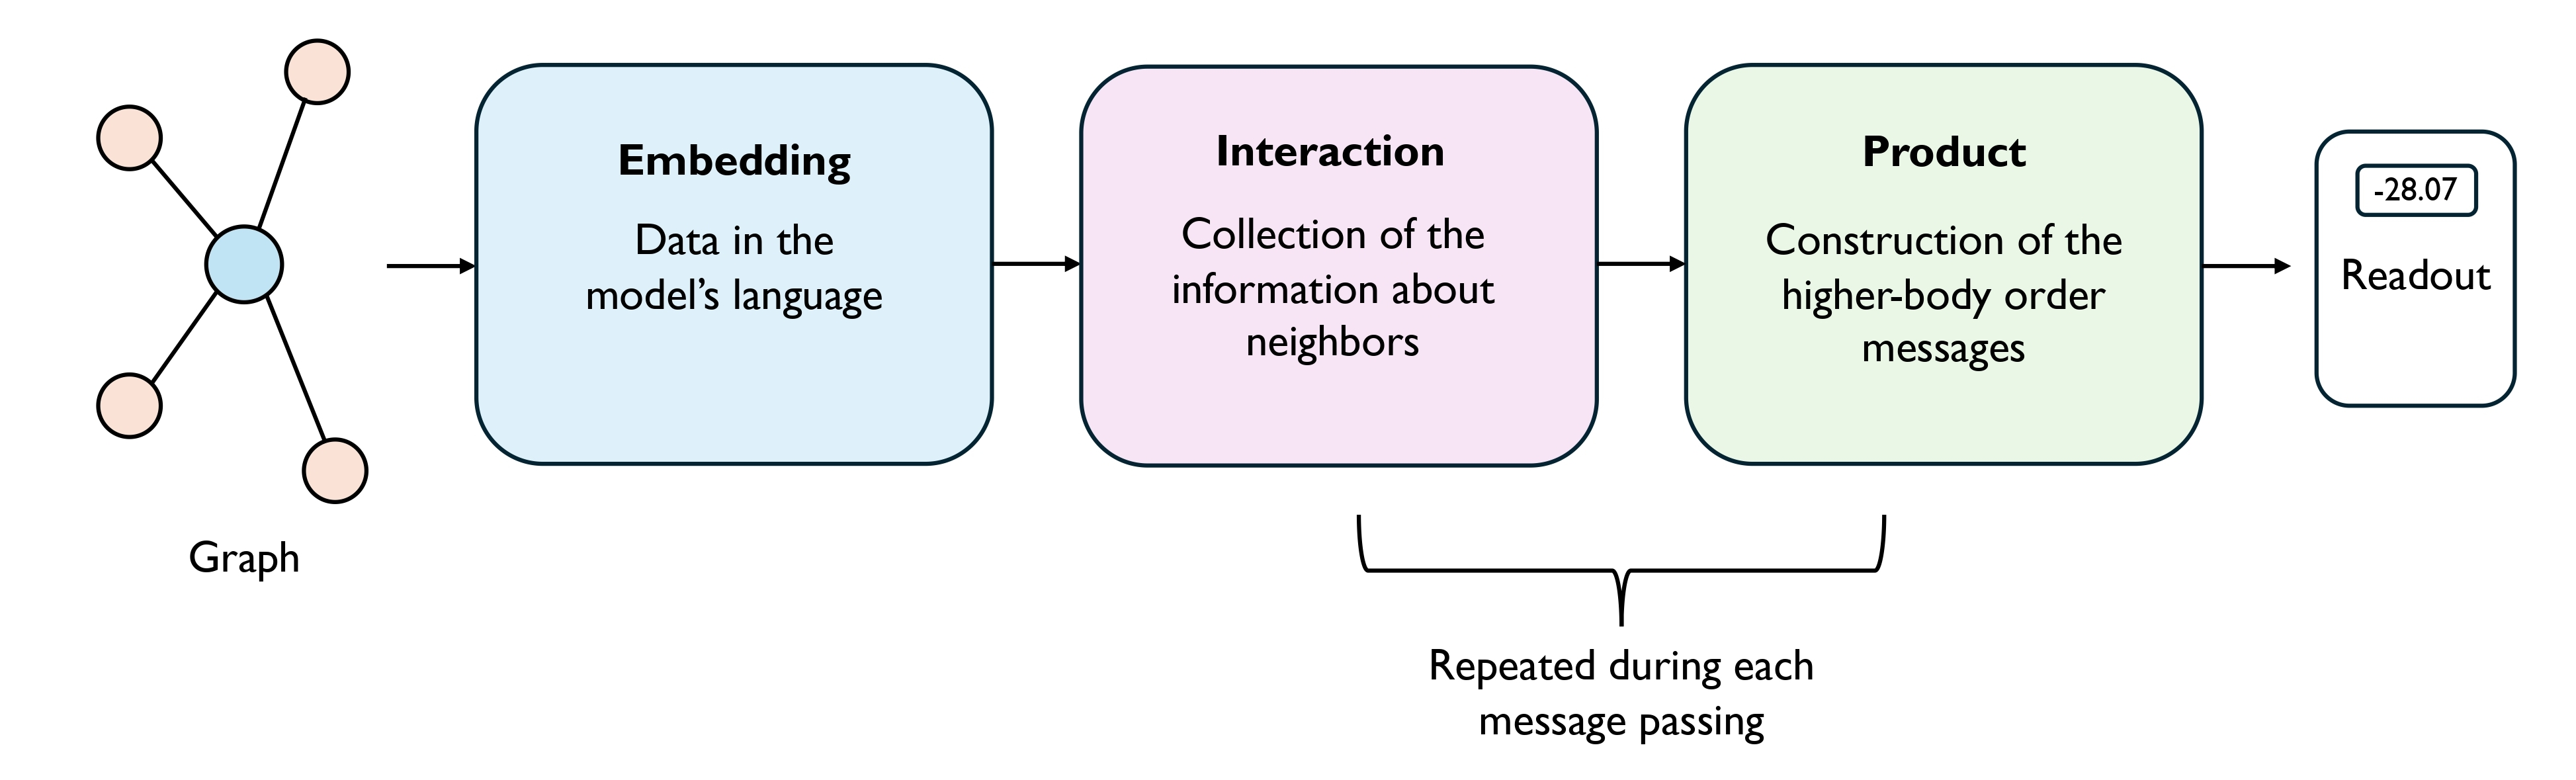

# Dataset

In [ ]:
# Defining path to dataset for ease
dataset_dir = Path(os.getcwd())/'Si_data'
dataset_dir

NameError: name 'Path' is not defined

In [ ]:
#Let's load and understand the dataset
from ase.io import read, write

# Load the dataset
dataset = read("Si_data/Si_aimd.xyz", index=":")
dataset[0]

Atoms(symbols='Si64', pbc=True, cell=[10.861999859992501, 10.861999859992501, 10.861999859992501], calculator=SinglePointCalculator(...))

In [ ]:
num_configs = len(dataset)
print(f"Number of configurations in the dataset: {num_configs}")

Number of configurations in the dataset: 110


## Split into Train and Test parts

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (100) and test (10)
train_set, test_set = train_test_split(dataset, test_size = 10, random_state = 123)

# Specify the train and test file path for ease
train_data_path = dataset_dir / "Si_train.xyz"
test_data_path = dataset_dir / "Si_test.xyz"

# Write them out to separate .xyz files
write(train_data_path, train_set)
write(test_data_path, test_set)

## Training

In [ ]:
# Specify paths
mace_dir = Path(os.getcwd()) / 'mace'
mace_configs_dir = mace_dir / 'configs'
mace_results_dir = mace_dir / 'results'

# Create directories if not exists
os.makedirs(mace_configs_dir, exist_ok=True)
os.makedirs(mace_results_dir, exist_ok=True)

For configuring the hyperparameters, we can specify a YAML file. The following is an example:

<details>
<summary>Click to see detailed explanations of the hyperparameters:</summary>
    
<br>

MACE has different hyper parameters that controls the degree of accuracy and expressivity of the model. Setting these parameters is a trade off between accuracy and computational cost. Most MACE parameters have robust and well tested defaults. We call them here "Parameters to keep to default values" but mention them for general knowledge. The "Hyper Parameters to Change" are hyper parameters that need to be adjusted as they can be task or system dependent.

#### Hyper Parameters to Change:

- **`num_channels`: Number of channels**
  
  Determines the size of the model. The recommended value is `--num_channels=128` but other potential values are `64` for a faster model or `256` for a large but more accurate model.
  
  
- **`max_L`: Symmetry of the messages**

  Determines the symmetry of the messages. A value of `--max_L=0` means MACE will pass only invariant information between neigborhoods. It is the parameter **that affects the most the computational speed and the accuracy of the model**. `--max_L=0` are the fastest model, use them to train cheap model to run large and long simulations. `--max_L=1` is the default value, it is a good compromise between speed and accuracy. It is recommended to start with that value for a new project. `--max_L=2` are the most accurate models, use them to train very accurate but slower models.
  

- **`r_max`: The cutoff radius**
  
  The cutoff used to create the local environment in each layer. `r_max=5.0` means atoms separated by a distance of more than 5.0 Å do not directly communicate in a single layer. When the model has multiple message-passing layers, atoms further than 5.0 Å can still communicate through later messages if intermediate proxy atoms exist. The effective receptive field of the model is `num_interactions * r_max`. The larger the `r_max`, the slower the model will be. It is recommended to use values between 4.0 Å and 7.0 Å.

---

#### Hyper Parameters to keep to default values (for general knowledge):

- **`num_interactions`: Message-passing layers**
  
  Controls the number of message-passing layers in the model. It should always be 2, and it is recommended not to modify it.


- **`correlation`: The order of the many-body expansion**

  The body order that MACE induces at each layer. Choosing `--correlation=3` will create basis functions of up to 4-body (ijkl) indices, for each layer. If the model has multiple layers, the effective correlation order is higher. For example, a two-layer MACE with `--correlation=3` has an effective body order of 13.


- **`max_ell`: Angular resolution**

  The angular resolution describes how well the model can describe angles. This is controlled by `max_ell` of the spherical harmonics basis (not to be confused with `max_L`). Larger values will result in more accurate but slower models. The default is `max_ell=3`, which is appropriate in most cases.

---

#### General training management:


- ##### `name`: the name of the model
    This name will be used to form file names (model, log, checkpoints, results), so choose a distinct name for each experiment

- ##### `model_dir, --log_dir, --checkpoints_dir, --results_dir`: directory paths
    These are the directories where each type of file is saved. For simplicity, we will save all files in the same directory.

---

#### Data management:

- ##### `train_file`: name of training dataset

    These are the configurations that will be use to train the model.

- ##### `valid_file`: name of validation dataset
    An alternative way to choose the validation set is by using the `--valid_fraction` keyword. These data configs are used to estimate the model accuracy during training, but not for parameter optimization. The validation set also controls the stopping of the training. At each `--eval_interval` the model is tested on the validation set. The evaluation of these configs takes place in batches, which can be controlled by `--valid_batch_size`. If the accuracy of the model stops improving on the validation set for `--patience` number of epochs, the model will undergo **early stopping**.

- ##### `test_file`: name of testing dataset

    This set is entirely independent and only gets evaluated at the end of the training process to estimate the model accuracy on an independent set.

- ##### `E0s`: isolated atom energies

    Controls how `E0s` should be determined. The strongly recommended approach is to add these values to the training set with `config_type=IsolatedAtom` in `atoms.info` and set `E0s="isolated"`. If these values are not available, MACE can estimate them by least square regression over the available data `E0s="average"` which can lead to unintended consequences depending on how representative the data is. This term is essential because MACE (and other MLIPs) fit to atomization energies ($E^{\rm atm}$) which is total energy ($E^{\rm tot}$) minus the energy of each atom in vacuum $(E^{0})$

  $$
  E^{\rm atm} = E^{\rm tot}-\sum_i^{N} E^{0}
  $$

- ##### `energy_key, forces_key` the key where these values are stores
    This key must coincide with the `ase.Atoms.info[key]/ase.Atoms.arrays[key]` where the energies and forces are stored in the ase.Atoms object. **It is very important to get them right**.

---

#### Optimization:

- ##### `device` computing device to use
    Can be CPU (`cpu`), GPU (`cuda`) or Apple Silicon (`mps`). Here we will use `cuda` since the GPU will be significantly faster than the CPU.

- ##### `batch_size` number of configs evaluated in one batch
    Number of configs used to compute the gradients for each full update of the network parameters. This training strategy is called stochastic gradient descent because only a subset of the data (`batch_size`) is used to change the parameters at each update.

- ##### `max_num_epochs` number of passes through the data
    An `epoch` is completed when the entire training data has been used once in updating the weights `batch` by `batch`. A new epoch begins, and the process repeats.

- ##### `swa` protocol for loss weights
    During training you will notice energy errors are at first much higher than force errors, MACE implements a special protocol that increases the weight on the energy in the loss function (`--swa_energy_weight`) once the forces are sufficiently accurate. The starting epoch for this special protocol can be controlled by changing `--start_swa`.

- ##### `seed` random number generator seed
    Useful for preparing committee of models.

**Now we are ready to fit our first MACE model!**


In [ ]:
# Specifying parameters for training a MACE model

parameters_mace = {

    # Specify model name and save directories
    "name": "si",  # Name of the model being trained
    "model_dir": str(mace_results_dir),
    "log_dir": str(mace_results_dir),
    "checkpoints_dir": str(mace_results_dir),
    "results_dir": str(mace_results_dir),

    # Train file specifications
    "train_file": str(train_data_path),  # Path to training data
    "forces_key": "forces",  # Key for forces in the dataset
    "energy_key": "energy",  # Key for energy in the dataset

    # Test file specification to evaluate test error with the best model
    "test_file": str(test_data_path), # Path to testing data

    # Energy of isolated atoms
    "E0s": "average",

    # Hyperparameters
    "model": "MACE",  # Type of model to train (https://mace-docs.readthedocs.io/en/latest/guide/training.html#model)
    "num_channels": 64, # Dimension of the chemical embedding vector
    "r_max": 4.0,  # Maximum interaction radius
    "max_L": 1, # Symmetry of messages

    "num_interactions": 2,  # Number of message-passing layers in the model (recommended to keep default)
    "correlation": 3, # The order of the many-body expansion, correlation = body order - 1 (recommended to keep default)
    "max_ell": 3, # The angular resolution describes how well the model can describe angles (recommended to keep default)

    # Optimization
    "valid_fraction": 0.05, # Fraction of the training set to use as validation
    "batch_size": 10, # Batch size for training
    "max_num_epochs": 30, # Maximum number of epochs
    "default_dtype": "float32", # Precision for calculations
    "device" : "cuda" if torch.cuda.is_available() else 'cpu',
    "seed": 123,
}

# Save parameters to a YAML file
input_mace = "./input.yaml"

with open(input_mace, "w") as file:
    yaml.dump(parameters_mace, file, default_flow_style=False)

print(f"Parameters have been saved to {input_mace}")

Parameters have been saved to ./input.yaml


### Training (and evaluation)

In [ ]:
# Define a mace trainer
import warnings
warnings.filterwarnings("ignore")
from mace.cli.run_train import main as mace_run_train_main
import sys
import logging

def train_mace(config_file_path):
    logging.getLogger().handlers.clear()
    sys.argv = ["program", "--config", config_file_path]
    mace_run_train_main()

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [ ]:
# execute the training
train_mace("./input.yaml")

MACE v1.0 replaces --config: the v1 config system makes this first-class (TOML/YAML/JSON, always available, resolved config saved as run metadata). See the MACE v1.0 migration guide.
MACE v1.0 replaces --checkpoints_dir: it becomes single work-dir layout convention. See the MACE v1.0 migration guide.
MACE v1.0 replaces --default_dtype: it becomes PrecisionConfig. See the MACE v1.0 migration guide.
MACE v1.0 replaces --energy_key: property-key convention of the observable spec. See the MACE v1.0 migration guide.
MACE v1.0 replaces --forces_key: property-key convention of the observable spec. See the MACE v1.0 migration guide.
MACE v1.0 replaces --log_dir: it becomes single work-dir layout convention. See the MACE v1.0 migration guide.
MACE v1.0 replaces --model: model composition is config-driven (BaseMACE + declared outputs), not a class name. See the MACE v1.0 migration guide.
MACE v1.0 replaces --model_dir: it becomes single work-dir layout convention. See the MACE v1.0 migration gui

2026-09-20 12:56:19.528 INFO: ===========VERIFYING SETTINGS===========
2026-09-20 12:56:19.528 INFO: MACE version: 0.3.17
2026-09-20 12:56:19.559 INFO: CUDA version: 12.8, CUDA device: 0
2026-09-20 12:56:19.599 INFO: ===========LOADING INPUT DATA===========
2026-09-20 12:56:19.599 INFO: Using heads: ['Default']
2026-09-20 12:56:19.600 INFO: Using the key specifications to parse data:
2026-09-20 12:56:19.602 INFO: Default: KeySpecification(info_keys={'energy': 'energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'forces', 'charges': 'REF_charges', 'magmom': 'REF_magmom', 'magforces': 'REF_magforces'})
2026-09-20 12:56:19.603 INFO: =============    Processing head Default     ===========
2026-09-20 12:56:19.683 WARNING: Since ASE version 3.23.0b1, using energy_key 'energy' is no longer safe when commun

Check the file saved as `..._train.txt` for information of about training.

The `..._train.txt` file contains two types of data:

1. Optimization Data: Batch Optimization data
2. Evaluation Data: Validation data

In [ ]:
mace_train_txt = f"{mace_results_dir}/{parameters_mace['name']}_run-{parameters_mace['seed']}_train.txt"

# Parsing the train file
eval_data, opt_data = parse_mace_train_file(mace_train_txt)

In [ ]:
# Take a look at the opt_data
pd.DataFrame(opt_data).transpose()

,loss,time
0,"[90.7524642944336, 66.86540985107422, 63.53081...","[1.025984764099121, 1.8059802055358887, 2.2756..."
1,"[34.18370819091797, 28.24411964416504, 16.6335...","[0.15764188766479492, 0.15114736557006836, 0.1..."
2,"[6.406445503234863, 5.664768695831299, 7.31691...","[0.15749454498291016, 0.1525430679321289, 0.15..."
3,"[4.1801533699035645, 3.325126886367798, 3.0987...","[0.15198707580566406, 0.15153193473815918, 0.1..."
4,"[2.447598457336426, 3.057673692703247, 1.98214...","[0.16151738166809082, 0.15935850143432617, 0.1..."
5,"[1.96583092212677, 1.767195224761963, 1.812040...","[0.15241622924804688, 0.15248751640319824, 0.2..."
6,"[1.4313336610794067, 1.5401502847671509, 1.471...","[0.15278029441833496, 0.15172982215881348, 0.1..."
7,"[1.5078470706939697, 1.2786247730255127, 1.281...","[0.15196943283081055, 0.15096354484558105, 0.1..."
8,"[1.0351134538650513, 1.2462388277053833, 1.061...","[0.152693510055542, 0.15203380584716797, 0.152..."
9,"[0.9141320586204529, 1.164242148399353, 0.9810...","[0.1527256965637207, 0.15226078033447266, 0.15..."


In [ ]:
# Take a look at the eval_data
pd.DataFrame(eval_data).transpose()

,loss,mae_e,mae_e_per_atom,rmse_e,rmse_e_per_atom,q95_e,mae_f,rel_mae_f,rmse_f,rel_rmse_f,q95_f,time,head
NaN,17.678356,1.570703,0.024542,1.609201,0.025144,2.073437,0.748929,102.681946,0.940166,102.59535,1.873898,1.118757,Default
0.0,6.789794,67.064064,1.047876,67.064835,1.047888,67.438278,0.459802,63.041218,0.573157,62.545632,1.13464,0.045149,Default
1.0,1.214005,46.181446,0.721585,46.18166,0.721588,46.329884,0.183825,25.20336,0.23557,25.706547,0.474559,0.587895,Default
2.0,0.820068,53.11504,0.829922,53.115097,0.829923,53.198242,0.145658,19.970451,0.184704,20.155809,0.370365,0.04414,Default
3.0,0.480532,58.489452,0.913898,58.489471,0.913898,58.55254,0.099052,13.580495,0.125198,13.662177,0.240011,0.05421,Default
4.0,0.377217,47.509178,0.742331,47.509201,0.742331,47.554688,0.093283,12.789546,0.115543,12.608647,0.214497,0.047187,Default
5.0,0.289022,37.058205,0.579034,37.058208,0.579035,37.084373,0.083551,11.455298,0.105349,11.496133,0.202933,0.044591,Default
6.0,0.245739,25.044922,0.391327,25.044928,0.391327,25.056641,0.081855,11.222802,0.103709,11.317235,0.202775,0.044344,Default
7.0,0.218519,15.074023,0.235532,15.074041,0.235532,15.102344,0.080988,11.103927,0.101839,11.113167,0.194962,0.044678,Default
8.0,0.192062,7.956836,0.124326,7.956846,0.124326,7.971094,0.076544,10.494586,0.097203,10.607306,0.191549,0.045371,Default


In [ ]:
# obtain validation loss and average train loss for each epoch
train_loss_data = []
valid_loss_data = []

for epoch in opt_data.keys():
  train_loss_data.append(opt_data[epoch]['loss'])
  valid_loss_data.append(eval_data[epoch]['loss'])

average_train_loss_data=[]

num_validation_configs = parameters_mace['valid_fraction'] * len(train_set)
num_train_configs = len(train_set) - num_validation_configs


for loss in train_loss_data:
  average_train_loss_data.append(np.sum(loss) / num_train_configs)

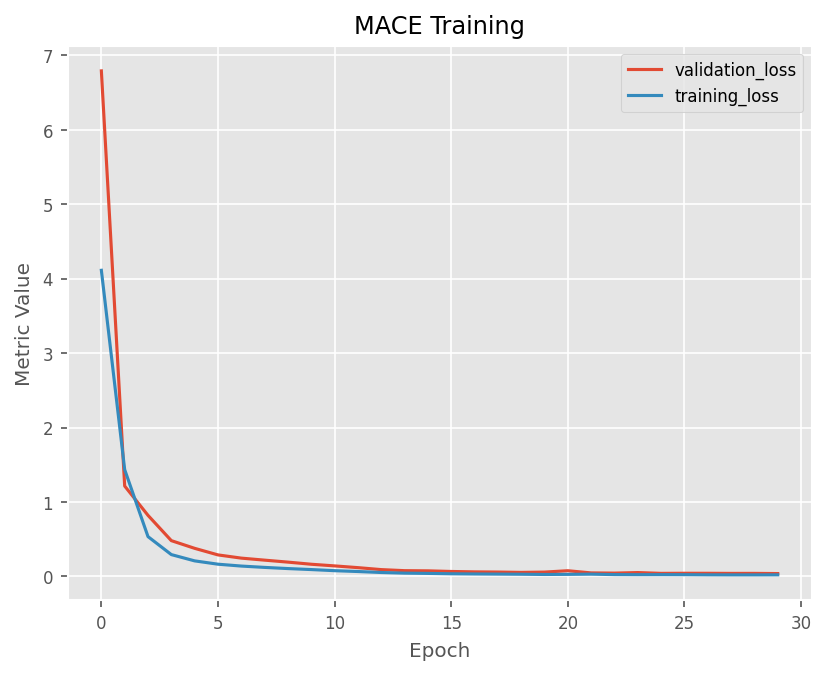

In [ ]:
# Plot the training and validation loss
plt.figure(dpi=150)
plt.plot(valid_loss_data, label='validation_loss')
plt.plot(average_train_loss_data, label='training_loss')
plt.xlabel('Epoch')
plt.ylabel('Metric Value')
plt.title('MACE Training')
plt.legend()
plt.show()

# Molecular Dynamics using MACE <a name="mace-md"></a>

Molecular dynamics (MD) is a computer simulation technique used to model and analyze the physical movements of atoms and molecules over time. By applying the principles of classical mechanics, specifically Newton's equations of motion, MD calculates the trajectories of particles based on the forces acting between them. These forces are typically derived from potential energy functions that describe interactions such as bonding, electrostatics, and van der Waals forces. The MLIPs are the potential energy functions we are using here.


MACE models can run molecular dynamics or geometry optimisation through the Atomic Simulation Environment (ASE) calculator. We will be using the `simpleMD()` function defined in mlip_utils.py for performing the MD simulations. `simpleMD()` uses the [`ase.md`](https://wiki.fysik.dtu.dk/ase/ase/md.html) module and is based on this [tutorial](https://colab.research.google.com/drive/1ZrTuTvavXiCxTFyjBV4GqlARxgFwYAtX).

In [ ]:
# Select the first test strcucture for the MD simulation
init_conf = read(test_data_path, index=0)
init_conf

Atoms(symbols='Si64', pbc=True, cell=[10.861999859992501, 10.861999859992501, 10.861999859992501], calculator=SinglePointCalculator(...))

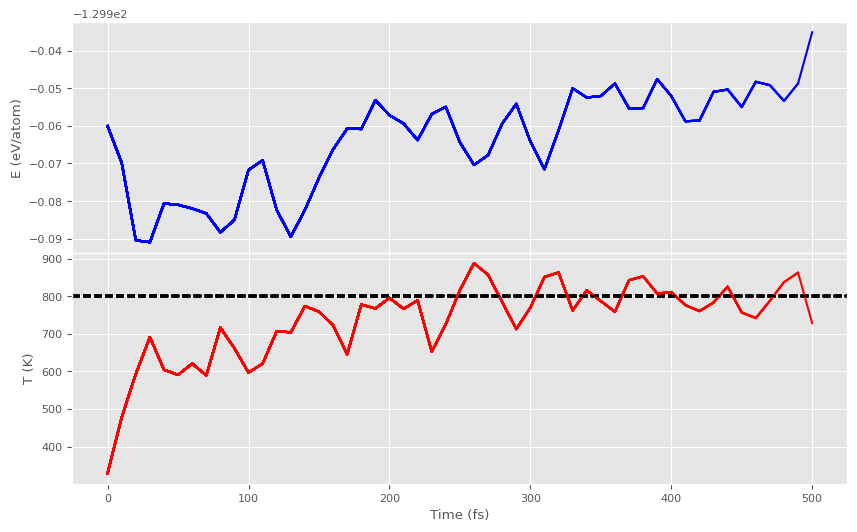

MD finished in 0.77 minutes!


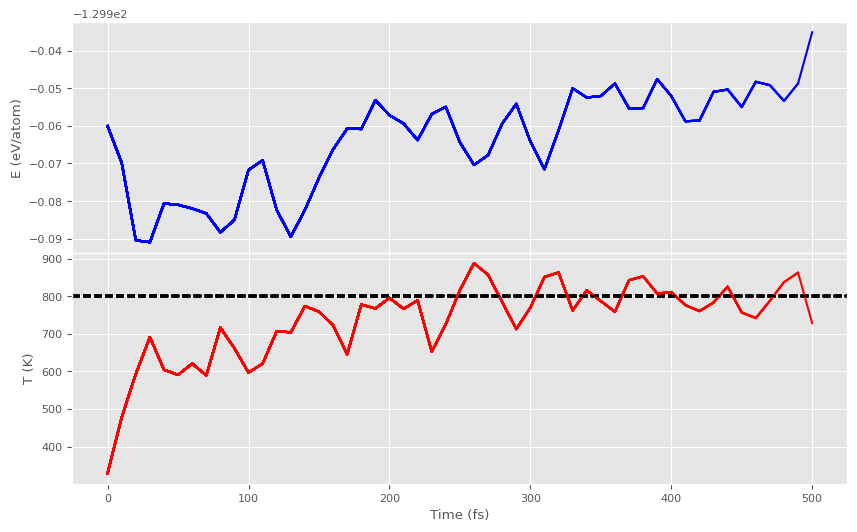

In [ ]:
%matplotlib inline
from mace.calculators import MACECalculator

# Specify the path to the pre-trained MACE model
mace_model = f"{mace_results_dir}/{parameters_mace['name']}_compiled.model"

# Initialize the MACE calculator with the specified model
mace_calc = MACECalculator(model_paths=[mace_model], device='cuda', default_dtype="float32")

# Call the simpleMD function to perform a molecular dynamics simulation
simpleMD(init_conf, temp=800, calc=mace_calc, fname= './mace_md_si_800K.xyz', s=10, T=500)

# MD using MACE Foundational Models

Foundational models are general-purpose ML model, pre-trained on a public database of 150k inorganic crystals, that is capable of running stable molecular dynamics on molecules and materials. We will be using one such model called [**MACE-MP: Materials Project Force Fields**](https://arxiv.org/abs/2401.00096) to demonstrate the power and generalizability of MACE.

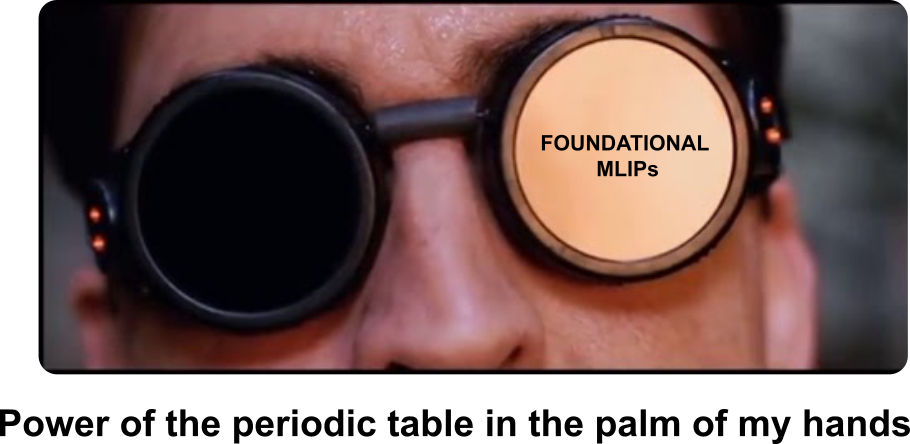

In [ ]:
init_conf = read(test_data_path, index=0)
init_conf

Atoms(symbols='Si64', pbc=True, cell=[10.861999859992501, 10.861999859992501, 10.861999859992501], calculator=SinglePointCalculator(...))

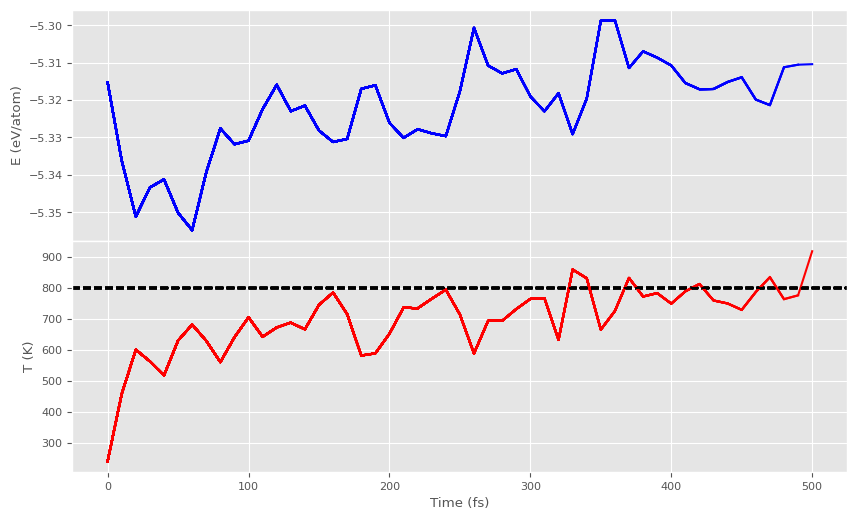

MD finished in 0.59 minutes!


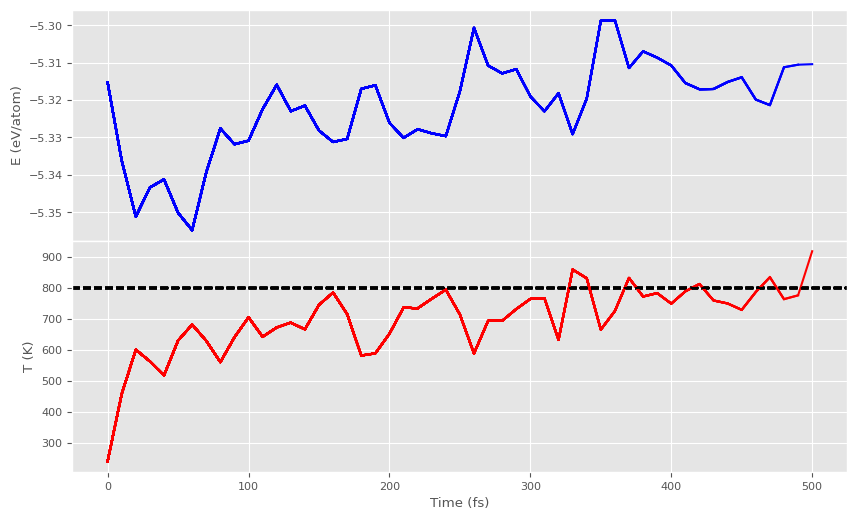

In [ ]:
# import the mace_mp foundational model
from mace.calculators import mace_mp

# Initialize the MACE-MP calculator
mace_mp_calc = mace_mp(device='cuda', default_dtype="float32")

# Call the simpleMD function to perform a molecular dynamics simulation
simpleMD(init_conf, temp=800, calc=mace_mp_calc, fname ='./mace_mp_md_si_800K.xyz', s=10, T=500)

# Try it yourself!

1. Try max_ell = 0 and max_L = 0, does having only invariant information suffice?

2. Try running the model with different hyperparameters and improve the model performance. What hyperparameters should you change and what hyperparamters should you not change?  

3. Try training MACE with more complicated datasets! <br> Download the BOTNET dataset (you can try to use the following code or manually download the datasets from the github link):

    ```
    !git clone https://github.com/davkovacs/BOTNet-datasets.git
    ```
    <br>

    The [BOTNET](https://github.com/davkovacs/BOTNet-datasets) collection of dataset used in the paper by [Batatia et.al](https://arxiv.org/abs/2205.06643). The collection contains the following datasets:
    
    1. **Ethanol and Methanol:** Consists of two training datasets, first taken revMD17 dataset and was sampled from a long 500 K Ab Initio molecular dynamics (AIMD) trajectory and the second training set contains the 1000 ethanol geometries of the first training set but is augmented by 300 K methanol geometries also sampled from 500 K Ab Initio molecular dynamics simulation.
    2. **3BPA:** Dataset contains snapshots of a large flexible drug-like organic molecule sampled from different temperature molecular dynamics trajectories.
    3. **Acetylacetone:** Dataset contains data related to acetylacetone (acac), specifically focusing on proton transfer reactions between its tautomeric forms. This dataset includes configurations obtained from Ab Initio molecular dynamics simulations at 300 K.
    
    Look at **[3BPA dataset](https://github.com/davkovacs/BOTNet-datasets/tree/main/dataset_ethanol)**. Train on the `train_300K.xyz` dataset and run MD simulations on the `test_300K.xyz` file. Is the run stable? Now change the hyperparameters to make the model more complicated (or better)


# Visualizing `.xyz` files

We can visualize the Molecular Dynamics file using softwares such as [OVITO](https://www.ovito.org/).

1. This can be done by downloading and installing OVITO software on your local device from the following website - [Download OVITO](https://www.ovito.org/#download)

2. After downloading it, open the application. [Refer this for usage instructions](https://www.ovito.org/manual).

3. Go to `Files`->`Load File...`-> Load the Trajectory File.

4. Play the animation.

# Downloading files from colab to local devices for visualization


In [ ]:
from google.colab import files

files.download('mace_md_si_800K.xyz')
files.download('mace_mp_md_si_800K.xyz')

# Incase you are interested further...

**Other MLIP architectures**
- **`SchNet` (Invariant)** : https://doi.org/10.1063/1.5019779

**Implementation of Equivariant Neural Networks**
- **`e3nn`** : https://e3nn.org/

**About Geometric Graphs**
- **`A Hitchhiker's Guide to Geometric GNNs for 3D Atomic Systems`** : https://doi.org/10.48550/arXiv.2312.07511

